# 06 — Modèle M1 : prédire le signe du gap d'ouverture

**La question.** À la clôture de 16h00, connaissant uniquement le flux de messages de la nuit précédente
et l'historique de marché, peut-on prédire si l'action ouvrira **en hausse** ou **en baisse** le lendemain
à 9h30 ?

**Pourquoi cette cible et pas une autre.** Le notebook 04 (corrigé au 04bis) a montré que le sentiment
nocturne sépare nettement les jours de gap positif des jours de gap négatif (écart de 28 à 42 points de
pourcentage entre quintiles extrêmes, monotone sur les 5 actions), alors qu'il ne dit rien de la séance
(ρ ≈ −0.01). Modéliser le gap, c'est modéliser là où le signal se trouve.

## Ce qui est différent de la phase 5 initiale

| | Phase 5 (2023-2026) | Phase 5bis (ce notebook) |
|---|---|---|
| Cible | `ret_cc` / `ret_oc` (séance) | **`y_gap`** (gap d'ouverture) |
| Densité du corpus | médiane 2 messages/jour | **170 à 1 474 messages/nuit** |
| Normalisation | valeurs brutes | **z-score glissant intra-ticker** |
| Validation | split aléatoire | **temporelle + walk-forward** |
| Métrique principale | accuracy | **AUC, MCC, Brier** |
| Résultat attendu | MCC ≈ 0.03, AUC ≈ 0.52 | à mesurer ci-dessous |

## Plan

| § | Contenu |
|---|---------|
| 1 | Les métriques : pourquoi l'accuracy ment ici |
| 2 | Les modèles de référence (à battre) |
| 3 | Régression logistique — le modèle interprétable |
| 4 | Modèles à base d'arbres — capter la non-linéarité |
| 5 | Validation walk-forward — la stabilité dans le temps |
| 6 | Ablations — d'où vient réellement le pouvoir prédictif ? |
| 7 | Calibration — les probabilités sont-elles honnêtes ? |
| 8 | Tests de robustesse |
| 9 | Évaluation finale sur le test (une seule fois) |

In [34]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

df = pd.read_csv(os.path.join(DATA, "DATASET_MODELISATION_2020_2022.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

with open(os.path.join(DATA, "config_modelisation.json"), encoding="utf-8") as f:
    CFG = json.load(f)

FEATURES     = [c for c in CFG["features"] if c in df.columns]

_absentes = [c for c in CFG["features"] if c not in df.columns]
if _absentes:
    raise KeyError(f"{len(_absentes)} features déclarées dans config_modelisation.json "
                   f"sont absentes du CSV : {_absentes}\nRéexécuter le notebook 05.")
FEAT_SENT    = [c for c in CFG["features_sentiment"] if c in df.columns]
FEAT_CTRL    = [c for c in CFG["controles"] if c in df.columns]
# La clé "features_conservateur" est remplacée par la spécification B
# (coupée à minuit) définie au notebook 05. On ne garde ici que sa part
# SENTIMENT : les contrôles sont rajoutés par FEAT_CTRL au moment de
# l'ablation, et les dupliquer fausserait le modèle.
FEAT_CONS    = [c for c in CFG.get("features_B_minuit",
                                   CFG.get("features_conservateur", []))
                if c in df.columns and c not in FEAT_CTRL]

print(f"{len(df):,} lignes | {len(FEATURES)} features "
      f"({len(FEAT_SENT)} sentiment + {len(FEAT_CTRL)} contrôles)")
print(df["bloc"].value_counts().reindex(["train","purge_1","valid","purge_2","test"]).to_string())

2,740 lignes | 18 features (10 sentiment + 8 contrôles)
bloc
train      1885
purge_1      10
valid       520
purge_2      15
test        310


---
## §1 — Choisir les bonnes métriques

### Pourquoi l'accuracy est trompeuse ici

Sur 2020-2022, environ **56 %** des jours ont un gap positif (marché haussier). Un modèle qui répond
« hausse » **tous les jours**, sans regarder aucune donnée, obtient donc **56 % d'exactitude**.

Si ton modèle atteint 57 %, il n'a presque rien appris — pourtant le chiffre a l'air respectable. C'est
exactement le piège dans lequel tombent la majorité des travaux sur la prédiction boursière.

### Les quatre métriques retenues

| Métrique | Ce qu'elle mesure | Valeur si aucune information |
|----------|-------------------|------------------------------|
| **AUC** | Capacité à **classer** : la probabilité qu'un jour de hausse tiré au hasard reçoive un score supérieur à un jour de baisse | **0.50** |
| **MCC** | Corrélation entre prédictions et réalité, robuste au déséquilibre des classes | **0.00** |
| **Brier** | Erreur quadratique moyenne sur les **probabilités** (pénalise la sur-confiance) | ≈ 0.247 |
| **Accuracy** | Reportée uniquement pour comparaison avec la référence naïve | 0.56 (ici) |

**Ordres de grandeur en finance quantitative journalière :**

- AUC 0.50-0.52 → rien
- AUC 0.53-0.55 → signal faible mais réel, potentiellement exploitable si les coûts sont bas
- AUC 0.55-0.60 → **bon signal** pour de la prédiction directionnelle
- AUC > 0.65 → **suspect** : chercher la fuite avant de se réjouir

Ce dernier point est important : en finance, un résultat trop beau est presque toujours un bug.

In [35]:
from sklearn.metrics import (roc_auc_score, matthews_corrcoef, brier_score_loss,
                             accuracy_score, confusion_matrix, roc_curve)

def evaluer(y_vrai, proba, seuil=0.5, nom=""):
    """Calcule le jeu complet de métriques pour un modèle de classification binaire."""
    y_vrai = np.asarray(y_vrai).astype(int)
    proba = np.asarray(proba, float)
    pred = (proba >= seuil).astype(int)
    return {
        "modele": nom,
        "n": len(y_vrai),
        "AUC": roc_auc_score(y_vrai, proba),
        "MCC": matthews_corrcoef(y_vrai, pred),
        "Brier": brier_score_loss(y_vrai, proba),
        "Accuracy": accuracy_score(y_vrai, pred),
        "base_rate": y_vrai.mean(),          # ce que ferait "toujours hausse"
        "taux_signal": pred.mean(),          # part de prédictions "hausse"
    }

def afficher(resultats):
    t = pd.DataFrame(resultats)
    for col in ["AUC", "MCC", "Brier", "Accuracy", "base_rate", "taux_signal"]:
        t[col] = t[col].round(4)
    t["gain_vs_naif"] = (t["Accuracy"] - t["base_rate"]).round(4)
    return t

CIBLE = "y_gap"
d = df.dropna(subset=[CIBLE]).copy()
tr = d[d["bloc"] == "train"]
va = d[d["bloc"] == "valid"]
te = d[d["bloc"] == "test"]

print(f"train {len(tr):4d} lignes | valid {len(va):4d} | test {len(te):4d}")
print(f"Taux de gaps positifs — train {tr[CIBLE].mean():.3f} | "
      f"valid {va[CIBLE].mean():.3f} | test {te[CIBLE].mean():.3f}")
print("""
Si ces trois taux diffèrent beaucoup, les blocs correspondent à des régimes de
marché différents. Ce n'est pas un défaut du découpage (le temps est ce qu'il est)
mais il faut l'indiquer dans le mémoire pour interpréter correctement les scores.
""")

train 1885 lignes | valid  520 | test  310
Taux de gaps positifs — train 0.595 | valid 0.606 | test 0.510

Si ces trois taux diffèrent beaucoup, les blocs correspondent à des régimes de
marché différents. Ce n'est pas un défaut du découpage (le temps est ce qu'il est)
mais il faut l'indiquer dans le mémoire pour interpréter correctement les scores.



---
## §2 — Les modèles de référence

Un modèle n'a de valeur que **relativement à ce qu'on obtiendrait sans lui**. On construit donc quatre
références, de la plus bête à la plus sérieuse.

| Référence | Règle | Ce qu'elle teste |
|-----------|-------|------------------|
| **R1 — Toujours hausse** | prédire 1 partout | la classe majoritaire suffit-elle ? |
| **R2 — Hasard** | probabilité tirée uniformément | contrôle négatif |
| **R3 — Momentum** | continuation du rendement de la veille | le signal est-il autre chose que du momentum ? |
| **R4 — Sentiment brut** | seuil sur `z_mu_night_full` seul, sans apprentissage | l'apprentissage apporte-t-il quelque chose ? |

**R4 est la plus intéressante.** Si un simple seuil sur le z-score du sentiment fait aussi bien qu'un
XGBoost à 300 arbres, alors le modèle complexe n'apporte rien — et il faut le dire. Un résultat simple et
robuste vaut mieux qu'un résultat complexe et fragile.

In [36]:
rng = np.random.default_rng(42)
refs = []

# R1 — toujours "hausse"
refs.append(evaluer(va[CIBLE], np.full(len(va), 0.99), nom="R1 toujours hausse"))
# R2 — hasard
refs.append(evaluer(va[CIBLE], rng.uniform(size=len(va)), nom="R2 hasard"))
# R3 — momentum (rendement de la veille, ramené en [0,1] par une logistique)
mom = va["ret_oc_lag1"].fillna(0.0).values
refs.append(evaluer(va[CIBLE], 1 / (1 + np.exp(-mom * 50)), nom="R3 momentum J-1"))
# R4 — sentiment brut, sans aucun apprentissage
sent = va["z_mu_night_full"].fillna(0.0).clip(-3, 3).values
refs.append(evaluer(va[CIBLE], 1 / (1 + np.exp(-sent)), nom="R4 sentiment brut (sans apprentissage)"))

tab_ref = afficher(refs)
print(tab_ref.to_string(index=False))
print("""
LECTURE :
  - R1 a une AUC de 0.50 : prédire toujours la même chose ne classe rien,
    même si son "accuracy" paraît bonne. C'est la démonstration du piège.
  - R4 est la vraie barre à franchir. Tout modèle appris doit la battre,
    sinon la complexité ajoutée n'est pas justifiée.
""")

                                modele   n    AUC     MCC  Brier  Accuracy  base_rate  taux_signal  gain_vs_naif
                    R1 toujours hausse 520 0.5000  0.0000 0.3864    0.6058     0.6058       1.0000        0.0000
                             R2 hasard 520 0.4936 -0.0323 0.3366    0.4846     0.6058       0.5019       -0.1212
                       R3 momentum J-1 520 0.4848 -0.0388 0.2798    0.4827     0.6058       0.5077       -0.1231
R4 sentiment brut (sans apprentissage) 520 0.6983  0.2382 0.2265    0.6192     0.6058       0.5135        0.0134

LECTURE :
  - R1 a une AUC de 0.50 : prédire toujours la même chose ne classe rien,
    même si son "accuracy" paraît bonne. C'est la démonstration du piège.
  - R4 est la vraie barre à franchir. Tout modèle appris doit la battre,
    sinon la complexité ajoutée n'est pas justifiée.



---
## §3 — Régression logistique

### Pourquoi commencer par là

C'est le modèle le moins puissant, et c'est précisément pour ça qu'il est le premier :

1. **Il est interprétable.** Chaque coefficient a un signe et une amplitude qu'on peut discuter dans le
   mémoire. Un XGBoost ne donne que des importances, beaucoup plus difficiles à défendre.
2. **Il surajuste peu.** Avec ~1 800 lignes d'entraînement et 20 features, un modèle non linéaire a toute
   latitude pour apprendre du bruit. La logistique régularisée, non.
3. **Il fixe le plancher.** Si les arbres ne battent pas la logistique, la relation est essentiellement
   linéaire — et on garde le modèle simple.

### La régularisation

On utilise une pénalité **L2 (ridge)**, réglée sur la validation. La pénalité empêche les coefficients de
devenir grands, ce qui est indispensable quand les features sont corrélées entre elles — ce qui est le
cas ici (`z_mu_night_full`, `z_mu_overnight` et `z_mu_pre` sont liées par construction).

### Trois spécifications emboîtées

| Modèle | Features | Question |
|--------|----------|----------|
| **L-ctrl** | contrôles de marché seuls | quelle part vient du momentum et de la volatilité ? |
| **L-sent** | sentiment seul | quelle part vient du texte ? |
| **L-tout** | les deux | le texte apporte-t-il quelque chose **en plus** ? |

C'est cette comparaison en trois temps qui répond à l'objection « vous avez juste redécouvert le
momentum ».

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def pipeline_logit(C=1.0):
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("std", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=C, solver="lbfgs")),
    ])

specs = {
    "L-ctrl (contrôles seuls)": FEAT_CTRL,
    "L-sent (sentiment seul)":  FEAT_SENT,
    "L-tout (les deux)":        FEATURES,
}

res_logit, modeles = [], {}
for nom, feats in specs.items():
    # choix de C sur la VALIDATION uniquement
    meilleur = (None, -np.inf, None)
    for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]:
        p = pipeline_logit(C).fit(tr[feats], tr[CIBLE])
        auc = roc_auc_score(va[CIBLE], p.predict_proba(va[feats])[:, 1])
        if auc > meilleur[1]:
            meilleur = (C, auc, p)
    C, _, modele = meilleur
    modeles[nom] = (modele, feats)
    r = evaluer(va[CIBLE], modele.predict_proba(va[feats])[:, 1], nom=nom)
    r["C"] = C
    res_logit.append(r)

tab = afficher(res_logit)
print(tab.to_string(index=False))

auc_c = tab.loc[tab["modele"].str.startswith("L-ctrl"), "AUC"].iloc[0]
auc_s = tab.loc[tab["modele"].str.startswith("L-sent"), "AUC"].iloc[0]
auc_t = tab.loc[tab["modele"].str.startswith("L-tout"), "AUC"].iloc[0]
print(f"""
DÉCOMPOSITION DU POUVOIR PRÉDICTIF (AUC sur validation)
  contrôles de marché seuls .............. {auc_c:.4f}
  sentiment seul ......................... {auc_s:.4f}
  les deux ............................... {auc_t:.4f}
  apport net du sentiment ................ {auc_t - auc_c:+.4f}

C'est la ligne "apport net" qui répond à l'objection "ce n'est que du momentum".
""")

                  modele   n    AUC    MCC  Brier  Accuracy  base_rate  taux_signal    C  gain_vs_naif
L-ctrl (contrôles seuls) 520 0.4828 0.0134 0.2400    0.6058     0.6058       0.9962 0.01        0.0000
 L-sent (sentiment seul) 520 0.6197 0.1087 0.2310    0.6077     0.6058       0.8135 3.00        0.0019
       L-tout (les deux) 520 0.6184 0.1555 0.2309    0.6250     0.6058       0.8077 3.00        0.0192

DÉCOMPOSITION DU POUVOIR PRÉDICTIF (AUC sur validation)
  contrôles de marché seuls .............. 0.4828
  sentiment seul ......................... 0.6197
  les deux ............................... 0.6184
  apport net du sentiment ................ +0.1356

C'est la ligne "apport net" qui répond à l'objection "ce n'est que du momentum".



### Lire les coefficients

Les features étant standardisées, les coefficients sont **directement comparables** entre eux. On les
convertit en **odds ratios** (`exp(coef)`), plus faciles à formuler en français :

> un odds ratio de **1.35** sur `z_mu_night_full` signifie : *« quand le sentiment nocturne augmente
> d'un écart-type, la cote d'un gap positif est multipliée par 1.35 »*.

Ce sont ces phrases-là qui vont dans le corps du mémoire.

           feature   famille    coef  odds_ratio
   z_mu_night_safe sentiment  1.3306      3.7834
    z_mu_overnight sentiment -0.7960      0.4511
   z_sd_night_safe sentiment -0.3439      0.7090
    z_sd_overnight sentiment  0.3090      1.3620
          ampl_ma5    marché  0.2226      1.2493
     z_mu_safe_ma3 sentiment -0.1561      0.8555
         ampl_lag1    marché -0.1124      0.8936
        z_dmu_safe sentiment  0.1052      1.1110
          gap_lag1    marché -0.1003      0.9046
 z_nabn_night_safe sentiment  0.0828      1.0864
  rk_mu_night_safe sentiment -0.0770      0.9259
          gap_lag2    marché  0.0616      1.0636
            vol_20    marché -0.0494      0.9518
rk_nabn_night_safe sentiment  0.0190      1.0192
       ret_oc_lag1    marché -0.0182      0.9819
      vol_dollar_z    marché -0.0154      0.9847
 z_nlog_night_safe sentiment -0.0134      0.9866
               dow    marché -0.0036      0.9964


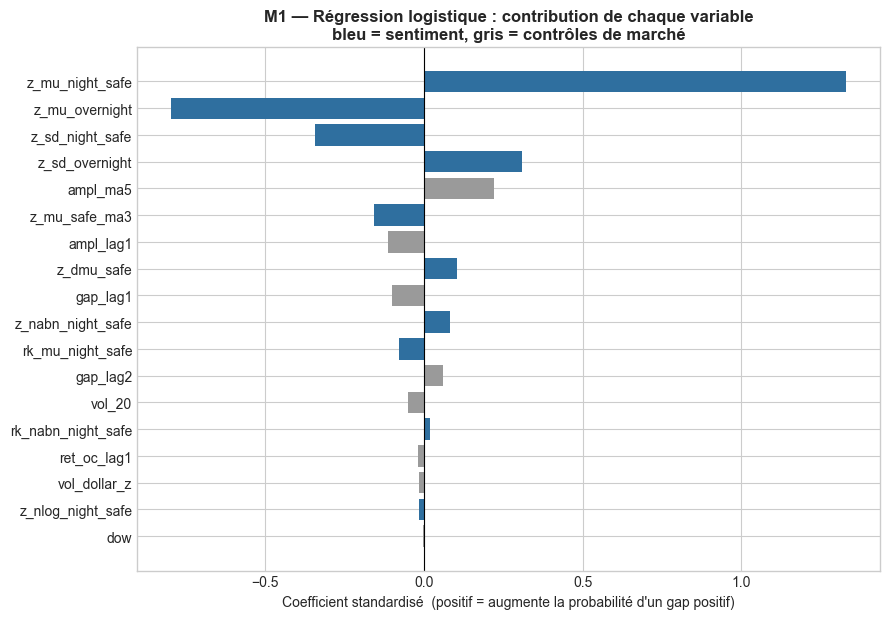


VIF (au-dessus de 5 : coefficient instable, à interpréter avec prudence) :
           feature   VIF
   z_mu_night_safe 42.82
    z_mu_overnight 32.11
   z_sd_night_safe 21.08
    z_sd_overnight 20.36
 z_nabn_night_safe  7.70
     z_mu_safe_ma3  6.49
 z_nlog_night_safe  5.59
          ampl_ma5  4.58
rk_nabn_night_safe  4.17
        z_dmu_safe  4.01
         ampl_lag1  3.41
            vol_20  2.97
  rk_mu_night_safe  2.73
      vol_dollar_z  1.97
               dow  1.18
       ret_oc_lag1  1.17
          gap_lag2  1.14
          gap_lag1  1.14

4 variables au-dessus de VIF=10.0 : coefficients NON interprétables.
        feature   VIF
z_mu_night_safe 42.82
 z_mu_overnight 32.11
z_sd_night_safe 21.08
 z_sd_overnight 20.36

  RÈGLE : on conserve mu (= pos - neg) et on écarte pos et neg ;
  on conserve la décomposition overnight/night_safe et on écarte l'union.
  Les PRÉDICTIONS changent à peine ; les COEFFICIENTS redeviennent lisibles.

    retrait de z_mu_night_safe            (VIF 42.8

In [38]:
modele, feats = modeles["L-tout (les deux)"]
coefs = pd.DataFrame({
    "feature": feats,
    "coef": modele.named_steps["clf"].coef_[0],
})
coefs["odds_ratio"] = np.exp(coefs["coef"])
coefs["|coef|"] = coefs["coef"].abs()
coefs["famille"] = np.where(coefs["feature"].str.startswith(("z_", "rk_")), "sentiment", "marché")
coefs = coefs.sort_values("|coef|", ascending=False)
print(coefs[["feature", "famille", "coef", "odds_ratio"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(coefs))))
top = coefs.head(18).iloc[::-1]
couleurs = np.where(top["famille"] == "sentiment", "#2f6f9f", "#9a9a9a")
ax.barh(top["feature"], top["coef"], color=couleurs)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient standardisé  (positif = augmente la probabilité d'un gap positif)")
ax.set_title("M1 — Régression logistique : contribution de chaque variable\n"
             "bleu = sentiment, gris = contrôles de marché", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "06_fig_coefficients_logit.png"), dpi=150, bbox_inches="tight")
plt.show()

# Multicolinéarité : indispensable puisque night_full = overnight + pre
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = pd.DataFrame(modele.named_steps["std"].transform(
        modele.named_steps["imp"].transform(tr[feats])), columns=feats)
vif = pd.DataFrame({"feature": feats,
                    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
print("\nVIF (au-dessus de 5 : coefficient instable, à interpréter avec prudence) :")
print(vif.sort_values("VIF", ascending=False).round(2).to_string(index=False))

from sklearn.base import clone   # requis ici : le §6 n'est pas encore exécuté
SEUIL_VIF = 10.0
mauvais = vif[vif["VIF"] > SEUIL_VIF].sort_values("VIF", ascending=False)

if len(mauvais):
    print(f"\n{len(mauvais)} variables au-dessus de VIF={SEUIL_VIF} : "
          f"coefficients NON interprétables.")
    print(mauvais.round(2).to_string(index=False))
    print("""
  RÈGLE : on conserve mu (= pos - neg) et on écarte pos et neg ;
  on conserve la décomposition overnight/night_safe et on écarte l'union.
  Les PRÉDICTIONS changent à peine ; les COEFFICIENTS redeviennent lisibles.
""")
    # Le pré-traitement est RÉAJUSTÉ à chaque tour sur les variables restantes.
    # Réutiliser l'imputeur et le standardiseur de `modele`, ajustés sur la liste
    # COMPLÈTE, lève « feature names should match those passed during fit » dès
    # le premier retrait — et serait de toute façon incorrect : la médiane et
    # l'échelle doivent être celles du sous-ensemble effectivement analysé.
    restant = list(feats)
    while len(restant) > 4:
        X_ = pd.DataFrame(
            StandardScaler().fit_transform(
                SimpleImputer(strategy="median").fit_transform(tr[restant])),
            columns=restant)
        v_ = pd.Series([variance_inflation_factor(X_.values, i)
                        for i in range(len(restant))], index=restant)
        if v_.max() <= SEUIL_VIF:
            break
        pire = v_.idxmax()
        print(f"    retrait de {pire:26s} (VIF {v_.max():.1f})")
        restant.remove(pire)

    FEATURES_VIF = restant
    print(f"\n  Jeu non colinéaire : {len(FEATURES_VIF)} variables, VIF max = {v_.max():.2f}")

    m_ = clone(pipeline_logit(1.0)).fit(tr[FEATURES_VIF], tr[CIBLE])
    auc_ = roc_auc_score(va[CIBLE], m_.predict_proba(va[FEATURES_VIF])[:, 1])
    print(f"  AUC avec le jeu nettoyé : {auc_:.4f}")

    co = pd.DataFrame({"feature": FEATURES_VIF, "coef": m_.named_steps["clf"].coef_[0]})
    co["odds_ratio"] = np.exp(co["coef"])
    co = co.reindex(co["coef"].abs().sort_values(ascending=False).index)
    print("\n  COEFFICIENTS INTERPRÉTABLES :")
    print(co.round(4).to_string(index=False))
    co.to_csv(os.path.join(DOCS, "06_coefficients_interpretables.csv"), index=False)

    print("""
  VÉRIFICATION ATTENDUE : le coefficient de z_mu_overnight doit être POSITIF,
  cohérent avec sa corrélation de +0,216 avec le gap (notebook 04 §17).
  S'il reste négatif, il subsiste de la colinéarité.
""")
else:
    print(f"\n[OK] Tous les VIF sont sous {SEUIL_VIF} : coefficients interprétables.")


---
## §4 — Modèles à base d'arbres

### Pourquoi ils devraient aider

Le tableau des quintiles du notebook 04 montrait :

```
Q1: −0.51 %   Q2: +0.27 %   Q3: +0.28 %   Q4: +0.23 %   Q5: +0.52 %
```

Q2, Q3 et Q4 sont **plats**. Le signal est concentré dans les **extrêmes**. Une régression logistique
suppose au contraire un effet **constant** par unité de z-score : elle est structurellement incapable de
représenter « rien au milieu, beaucoup aux bords ».

Les arbres, eux, découpent l'espace en zones et peuvent apprendre exactement ce type de règle :
« si `z_mu_night_full < −1.5` alors probabilité de gap positif = 0.35 ».

### Pourquoi il faut rester prudent

Avec ~1 800 lignes d'entraînement, un modèle à 500 arbres profonds mémorise le bruit. On impose donc des
contraintes fortes : profondeur limitée, minimum d'observations par feuille élevé, taux d'apprentissage
faible, et sous-échantillonnage. Le réglage se fait **sur la validation uniquement**.

In [39]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

res_arbres = []

# ---- Random Forest ----
grille_rf = [dict(n_estimators=400, max_depth=d, min_samples_leaf=f,
                  max_features="sqrt", class_weight="balanced_subsample",
                  random_state=42, n_jobs=-1)
             for d in (3, 4, 6) for f in (20, 40, 80)]
meilleur = (-np.inf, None, None)
for prm in grille_rf:
    m = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("clf", RandomForestClassifier(**prm))]).fit(tr[FEATURES], tr[CIBLE])
    auc = roc_auc_score(va[CIBLE], m.predict_proba(va[FEATURES])[:, 1])
    if auc > meilleur[0]:
        meilleur = (auc, m, prm)
auc_rf, rf, prm_rf = meilleur
res_arbres.append(evaluer(va[CIBLE], rf.predict_proba(va[FEATURES])[:, 1], nom="Random Forest"))
print("RF retenu :", {k: v for k, v in prm_rf.items() if k in ("max_depth", "min_samples_leaf")})

# ---- Gradient Boosting (HistGradientBoosting : dans scikit-learn, pas de dépendance externe) ----
grille_gb = [dict(max_depth=d, learning_rate=lr, max_iter=250,
                  min_samples_leaf=f, l2_regularization=1.0,
                  early_stopping=True, validation_fraction=0.15, random_state=42)
             for d in (2, 3) for lr in (0.02, 0.05) for f in (20, 40)]
meilleur = (-np.inf, None, None)
for prm in grille_gb:
    m = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("clf", HistGradientBoostingClassifier(**prm))]).fit(tr[FEATURES], tr[CIBLE])
    auc = roc_auc_score(va[CIBLE], m.predict_proba(va[FEATURES])[:, 1])
    if auc > meilleur[0]:
        meilleur = (auc, m, prm)
auc_gb, gb, prm_gb = meilleur
res_arbres.append(evaluer(va[CIBLE], gb.predict_proba(va[FEATURES])[:, 1], nom="Gradient Boosting"))
print("GB retenu :", {k: v for k, v in prm_gb.items() if k in ("max_depth", "learning_rate", "min_samples_leaf")})

# ---- Comparaison globale ----
tous = afficher(refs + res_logit + res_arbres).sort_values("AUC", ascending=False)
print("\n" + "=" * 100)
print("CLASSEMENT SUR LA VALIDATION")
print("=" * 100)
print(tous[["modele", "n", "AUC", "MCC", "Brier", "Accuracy", "base_rate", "gain_vs_naif"]].to_string(index=False))
tous.to_csv(os.path.join(DOCS, "06_comparaison_modeles_valid.csv"), index=False)

RF retenu : {'max_depth': 6, 'min_samples_leaf': 40}
GB retenu : {'max_depth': 3, 'learning_rate': 0.02, 'min_samples_leaf': 40}

CLASSEMENT SUR LA VALIDATION
                                modele   n    AUC     MCC  Brier  Accuracy  base_rate  gain_vs_naif
R4 sentiment brut (sans apprentissage) 520 0.6983  0.2382 0.2265    0.6192     0.6058        0.0134
                     Gradient Boosting 520 0.6301  0.1576 0.2279    0.6308     0.6058        0.0250
               L-sent (sentiment seul) 520 0.6197  0.1087 0.2310    0.6077     0.6058        0.0019
                     L-tout (les deux) 520 0.6184  0.1555 0.2309    0.6250     0.6058        0.0192
                         Random Forest 520 0.6094  0.1397 0.2404    0.5654     0.6058       -0.0404
                    R1 toujours hausse 520 0.5000  0.0000 0.3864    0.6058     0.6058        0.0000
                             R2 hasard 520 0.4936 -0.0323 0.3366    0.4846     0.6058       -0.1212
                       R3 momentum J-1 52

### Importance par permutation

L'importance intégrée aux arbres (`feature_importances_`) est biaisée : elle favorise les variables
continues à forte cardinalité. On utilise donc l'**importance par permutation**, qui mesure la chute de
performance quand on mélange aléatoirement une colonne — bien plus interprétable, et calculée **sur la
validation** (donc hors échantillon d'apprentissage).

           feature  perte_AUC  ecart_type   famille
   z_mu_night_safe     0.0721      0.0222 sentiment
        z_dmu_safe     0.0340      0.0128 sentiment
 z_nlog_night_safe     0.0135      0.0042 sentiment
  rk_mu_night_safe     0.0103      0.0061 sentiment
 z_nabn_night_safe     0.0068      0.0083 sentiment
      vol_dollar_z     0.0061      0.0032    marché
          ampl_ma5     0.0058      0.0049    marché
       ret_oc_lag1     0.0050      0.0037    marché
    z_sd_overnight     0.0045      0.0046 sentiment
   z_sd_night_safe     0.0033      0.0033 sentiment
    z_mu_overnight     0.0025      0.0037 sentiment
rk_nabn_night_safe     0.0022      0.0014 sentiment
          gap_lag1     0.0004      0.0017    marché
            vol_20     0.0003      0.0036    marché
               dow     0.0002      0.0007    marché
         ampl_lag1    -0.0001      0.0018    marché
     z_mu_safe_ma3    -0.0014      0.0012 sentiment
          gap_lag2    -0.0034      0.0036    marché


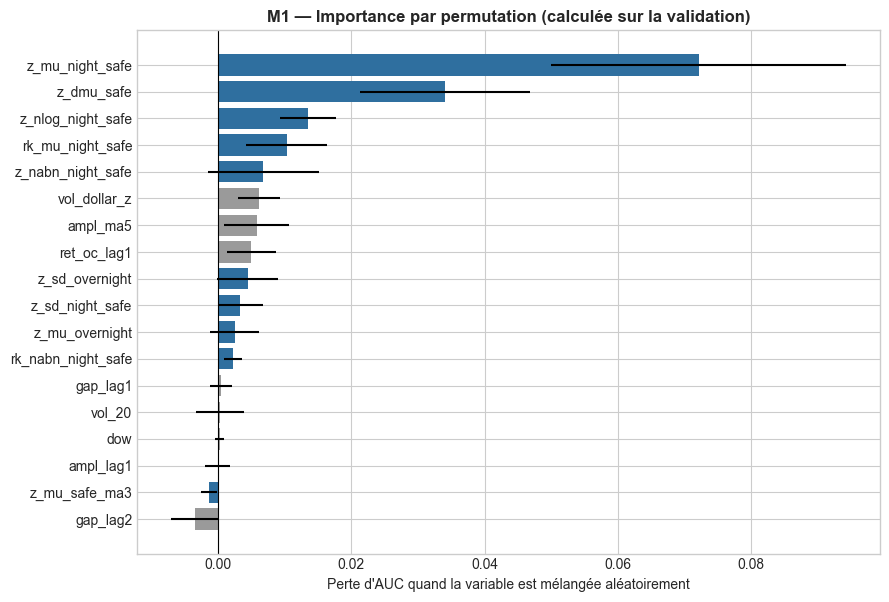


Part de l'importance totale : sentiment 0.1478 | marché 0.0143


In [40]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(gb, va[FEATURES], va[CIBLE], n_repeats=30,
                             random_state=42, scoring="roc_auc", n_jobs=-1)
imp_df = (pd.DataFrame({"feature": FEATURES,
                        "perte_AUC": imp.importances_mean,
                        "ecart_type": imp.importances_std})
          .sort_values("perte_AUC", ascending=False))
imp_df["famille"] = np.where(imp_df["feature"].str.startswith(("z_", "rk_")), "sentiment", "marché")
print(imp_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(5, 0.34 * len(imp_df))))
top = imp_df.head(18).iloc[::-1]
ax.barh(top["feature"], top["perte_AUC"], xerr=top["ecart_type"],
        color=np.where(top["famille"] == "sentiment", "#2f6f9f", "#9a9a9a"))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Perte d'AUC quand la variable est mélangée aléatoirement")
ax.set_title("M1 — Importance par permutation (calculée sur la validation)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "06_fig_importance_permutation.png"), dpi=150, bbox_inches="tight")
plt.show()

part = imp_df.groupby("famille")["perte_AUC"].sum()
print(f"\nPart de l'importance totale : sentiment {part.get('sentiment', 0):.4f} | "
      f"marché {part.get('marché', 0):.4f}")

---
## §5 — Validation walk-forward

### Le problème d'un seul découpage

Le score obtenu sur une unique période de validation dépend de cette période. Si juillet-novembre 2021 a
été calme, le score sera flatteur ; si cette période a été agitée, il sera pessimiste. **Un seul chiffre
ne dit rien de la stabilité du signal.**

### Le principe du walk-forward

```
Pli 1 : [====== entraînement ======]--purge--[test]
Pli 2 : [========= entraînement =========]--purge--[test]
Pli 3 : [============ entraînement ============]--purge--[test]
```

À chaque pli, on entraîne sur tout le passé disponible et on teste sur la période suivante. On obtient
autant de mesures hors échantillon qu'il y a de plis.

**C'est la seule validation acceptable en finance**, parce que c'est la seule qui reproduit la situation
réelle : au 1ᵉʳ mars, on ne dispose que des données antérieures au 1ᵉʳ mars.

### Ce qu'il faut regarder

Pas seulement la **moyenne** des AUC, mais leur **dispersion** et le **nombre de plis au-dessus de 0.50**.
Un modèle avec AUC moyenne 0.56 obtenue par 0.72 / 0.48 / 0.49 / 0.55 / 0.56 n'est pas un bon modèle :
c'est un modèle qui a eu de la chance une fois.

Walk-forward : 4 plis
  Pli 1 : train 2020-01-02 -> 2020-12-09 (238 j)  |  test 2020-12-17 -> 2021-03-16 (60 j)
  Pli 2 : train 2020-01-02 -> 2021-03-09 (298 j)  |  test 2021-03-17 -> 2021-06-10 (60 j)
  Pli 3 : train 2020-01-02 -> 2021-06-03 (358 j)  |  test 2021-06-11 -> 2021-09-03 (60 j)
  Pli 4 : train 2020-01-02 -> 2021-08-27 (418 j)  |  test 2021-09-07 -> 2021-11-30 (60 j)

Dernier jour du walk-forward : 2021-11-30
Premier jour du bloc test    : 2021-12-06
[OK] Le bloc de test est intact.
DÉTAIL PAR PLI (AUC)
modele  Contrôles seuls  Gradient Boosting  Logistique (tout)  Random Forest  Sentiment seul
pli                                                                                         
1                0.4831             0.5357             0.5800         0.5420          0.6039
2                0.4882             0.5732             0.5850         0.5870          0.6073
3                0.5370             0.6151             0.5815         0.5889          0.5798
4             

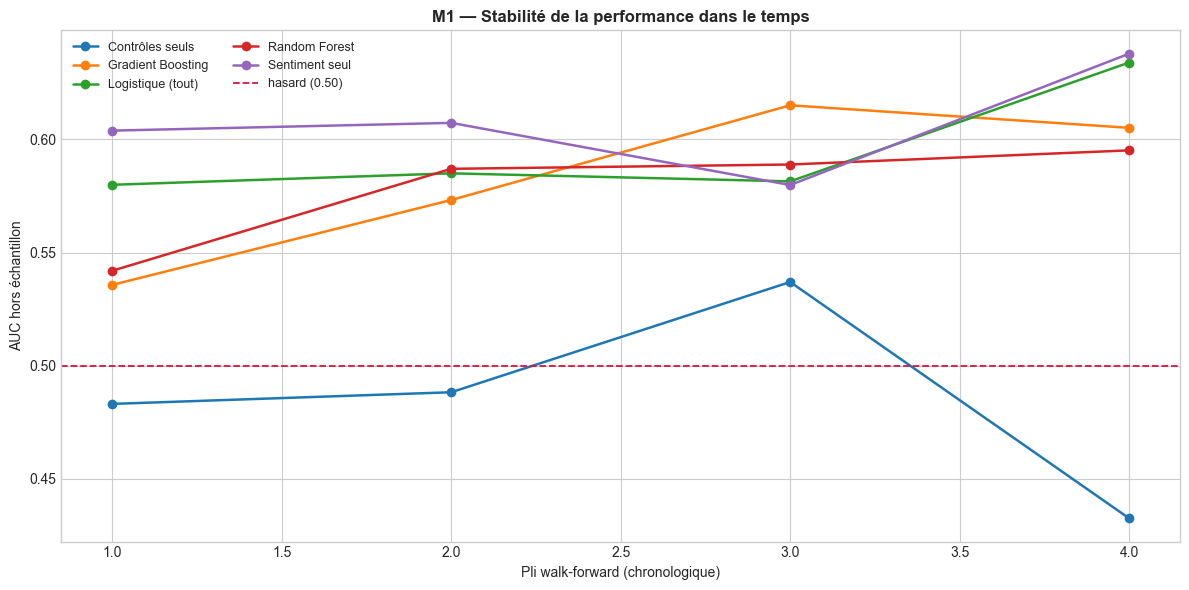


LECTURE : la colonne "stabilite" = (AUC moyenne - 0.5) / écart-type des AUC.
C'est un ratio signal/bruit. Au-dessus de 1, le signal domine la variabilité
entre périodes. En dessous de 0.5, on ne peut rien affirmer.



In [41]:
PURGE = CFG["purge_jours"]

def plis_walk_forward(dates, n_plis=6, taille_test=60, min_train=250):
    jours = np.sort(pd.unique(dates)); plis, fin = [], len(jours)
    for _ in range(n_plis):
        d0 = fin - taille_test
        if d0 - PURGE < min_train:
            break
        plis.append((jours[:d0 - PURGE], jours[d0:fin])); fin = d0
    return plis[::-1]

# --------------------------------------------------------------------------
# Le walk-forward NE DOIT PAS toucher le bloc de test, sinon l'évaluation
# finale du §9 n'est plus en aveugle. Dans la version précédente, le pli 4
# (2021-12-08 -> 2022-03-04) recouvrait le bloc test (2021-12-06 -> 2022-03-04)
# à deux jours près.
# --------------------------------------------------------------------------
d_wf = (df[df["bloc"].isin(["train", "purge_1", "valid"])]
          .dropna(subset=[CIBLE]).copy())

plis = plis_walk_forward(d_wf["Date"], n_plis=6, taille_test=60, min_train=200)

_dernier = pd.Timestamp(plis[-1][1][-1])
_premier = df.loc[df["bloc"] == "test", "Date"].min()
print(f"Walk-forward : {len(plis)} plis")
for i, (a, b) in enumerate(plis, 1):
    print(f"  Pli {i} : train {pd.Timestamp(a[0]).date()} -> {pd.Timestamp(a[-1]).date()} "
          f"({len(a):3d} j)  |  test {pd.Timestamp(b[0]).date()} -> "
          f"{pd.Timestamp(b[-1]).date()} ({len(b)} j)")
print(f"\nDernier jour du walk-forward : {_dernier.date()}")
print(f"Premier jour du bloc test    : {_premier.date()}")
assert _dernier < _premier, \
    "Le walk-forward empiète sur le bloc de test : le §9 ne serait plus en aveugle."
print("[OK] Le bloc de test est intact.")

candidats = {
    "Logistique (tout)": (pipeline_logit(1.0), FEATURES),
    "Random Forest":     (Pipeline([("imp", SimpleImputer(strategy="median")),
                                    ("clf", RandomForestClassifier(**prm_rf))]), FEATURES),
    "Gradient Boosting": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                    ("clf", HistGradientBoostingClassifier(**prm_gb))]), FEATURES),
    "Sentiment seul":    (pipeline_logit(1.0), FEAT_SENT),
    "Contrôles seuls":   (pipeline_logit(1.0), FEAT_CTRL),
}

lignes = []
for nom, (proto, feats) in candidats.items():
    for i, (j_tr, j_te) in enumerate(plis, 1):
        a = d_wf[d_wf["Date"].isin(j_tr)]
        b = d_wf[d_wf["Date"].isin(j_te)]
        if len(a) < 200 or b[CIBLE].nunique() < 2:
            continue
        from sklearn.base import clone
        m = clone(proto).fit(a[feats], a[CIBLE])
        p = m.predict_proba(b[feats])[:, 1]
        r = evaluer(b[CIBLE], p, nom=nom); r["pli"] = i
        r["periode"] = f"{pd.Timestamp(j_te[0]).date()} → {pd.Timestamp(j_te[-1]).date()}"
        lignes.append(r)

wf = pd.DataFrame(lignes)
print("DÉTAIL PAR PLI (AUC)")
print(wf.pivot(index="pli", columns="modele", values="AUC").round(4).to_string())

print("\n" + "=" * 88)
print("SYNTHÈSE WALK-FORWARD")
print("=" * 88)
syn = wf.groupby("modele").agg(
    plis=("AUC", "size"),
    AUC_moy=("AUC", "mean"), AUC_med=("AUC", "median"), AUC_std=("AUC", "std"),
    AUC_min=("AUC", "min"), AUC_max=("AUC", "max"),
    plis_gagnants=("AUC", lambda s: (s > 0.5).sum()),
    MCC_moy=("MCC", "mean"),
).sort_values("AUC_moy", ascending=False).round(4)
syn["stabilite"] = (syn["AUC_moy"] - 0.5) / syn["AUC_std"].replace(0, np.nan)
print(syn.to_string())
syn.to_csv(os.path.join(DOCS, "06_walkforward_synthese.csv"))

fig, ax = plt.subplots(figsize=(12, 6))
for nom, g in wf.groupby("modele"):
    ax.plot(g["pli"], g["AUC"], marker="o", label=nom, lw=1.8)
ax.axhline(0.5, color="crimson", ls="--", lw=1.3, label="hasard (0.50)")
ax.set_xlabel("Pli walk-forward (chronologique)"); ax.set_ylabel("AUC hors échantillon")
ax.set_title("M1 — Stabilité de la performance dans le temps", fontweight="bold")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "06_fig_walkforward.png"), dpi=150, bbox_inches="tight")
plt.show()
print("""
LECTURE : la colonne "stabilite" = (AUC moyenne - 0.5) / écart-type des AUC.
C'est un ratio signal/bruit. Au-dessus de 1, le signal domine la variabilité
entre périodes. En dessous de 0.5, on ne peut rien affirmer.
""")

---
## §6 — Ablations : d'où vient réellement le pouvoir prédictif ?

Une **ablation** consiste à retirer un ingrédient et à mesurer ce qu'on perd. C'est la manière la plus
directe de répondre aux objections qu'un jury va formuler.

| Ablation | Objection à laquelle elle répond |
|----------|----------------------------------|
| Sentiment retiré | « le signal vient-il du texte ou du marché ? » |
| Volume de messages retiré | « n'est-ce pas juste l'intensité d'attention ? » |
| Fenêtre `pre` retirée (jeu conservateur) | « vos messages de 9h00 ne sont-ils pas déjà dans le prix ? » |
| Direction du sentiment inversée | contrôle de cohérence : la performance doit **chuter** |
| Sentiment permuté aléatoirement | contrôle négatif : l'AUC doit retomber à 0.50 |

Les deux derniers sont des **tests de falsification**. Si inverser le signe du sentiment n'abîme pas le
modèle, c'est que le sentiment ne servait à rien et que le modèle s'appuyait sur autre chose.

> **Le piège à éviter sur le test d'inversion.** Si l'on inverse le signe du sentiment **à la fois** dans
> l'entraînement et dans le test, l'AUC ne bouge pas d'un iota : la régression apprend simplement le
> coefficient opposé, et le classement reste identique. Le test ne mesure alors rien du tout.
>
> L'inversion doit donc porter **uniquement sur le jeu de test** : on entraîne le modèle normalement, puis
> on lui présente des données dont le sentiment a été retourné. Si le modèle utilise réellement le
> sentiment dans le bon sens, sa performance doit **passer sous 0.50**.
>
> Le placebo par permutation, lui, s'applique bien des deux côtés : le but est de détruire la relation
> partout, pas de tester une direction.

In [42]:
from sklearn.base import clone

def auc_walkforward(feats, transformation=None, ou="test", proto=None):
    """AUC moyenne en walk-forward.

    ou="test" : la transformation n'est appliquée QU'AU jeu de test.
                C'est le réglage des tests de FALSIFICATION : le modèle est
                entraîné normalement, puis on lui donne des données trafiquées.
    ou="deux" : la transformation est appliquée au train ET au test.
                C'est le réglage du PLACEBO (on détruit la relation partout).

    ATTENTION -- piège classique : inverser le signe du sentiment dans le train
    ET dans le test ne change RIEN à l'AUC, car la régression apprend simplement
    le coefficient opposé. Le test d'inversion doit donc porter sur le test seul.
    """
    proto = proto or pipeline_logit(1.0)
    scores = []
    for j_tr, j_te in plis:
        a = d_wf[d_wf["Date"].isin(j_tr)].copy()
        b = d_wf[d_wf["Date"].isin(j_te)].copy()
        if len(a) < 200 or b[CIBLE].nunique() < 2:
            continue
        if transformation is not None:
            b = transformation(b)
            if ou == "deux":
                a = transformation(a)
        m = clone(proto).fit(a[feats], a[CIBLE])
        scores.append(roc_auc_score(b[CIBLE], m.predict_proba(b[feats])[:, 1]))
    return np.mean(scores), np.std(scores)

def inverser_sentiment(x):
    x = x.copy()
    for c_ in FEAT_SENT:
        x[c_] = -x[c_]
    return x

def permuter_sentiment(x):
    x = x.copy()
    r = np.random.default_rng(7)
    for c_ in FEAT_SENT:
        x[c_] = r.permutation(x[c_].values)
    return x

FEAT_SANS_VOLUME = [f for f in FEATURES if not any(k in f for k in ("nlog", "nabn", "n_"))]

ablations = [
    #  libellé                            features               transformation        appliquée à
    ("Toutes les variables",            FEATURES,              None,                 "test"),
    ("SANS sentiment (marché seul)",    FEAT_CTRL,             None,                 "test"),
    ("Sentiment SEUL",                  FEAT_SENT,             None,                 "test"),
    ("SANS volume de messages",         FEAT_SANS_VOLUME,      None,                 "test"),
    ("Jeu CONSERVATEUR (coupé minuit)", FEAT_CONS + FEAT_CTRL, None,                 "test"),
    ("Sentiment INVERSÉ (falsif.)",     FEATURES,              inverser_sentiment,   "test"),
    ("Sentiment PERMUTÉ (placebo)",     FEATURES,              permuter_sentiment,   "deux"),
]

lignes = []
for nom, feats, tf, ou in ablations:
    feats = [f for f in dict.fromkeys(feats) if f in d_wf.columns]
    if not feats:
        continue
    m, s = auc_walkforward(feats, tf, ou=ou)
    lignes.append(dict(Variante=nom, n_features=len(feats), applique_a=ou,
                       AUC_moy=round(m, 4), AUC_std=round(s, 4)))

abl = pd.DataFrame(lignes)
ref_auc = abl.loc[abl["Variante"] == "Toutes les variables", "AUC_moy"].iloc[0]
abl["delta_vs_complet"] = (abl["AUC_moy"] - ref_auc).round(4)
print(abl.to_string(index=False))
abl.to_csv(os.path.join(DOCS, "06_ablations.csv"), index=False)

print("""
CE QU'IL FAUT VÉRIFIER :
  1. "SANS sentiment" doit être NETTEMENT inférieur    -> le texte apporte quelque chose
  2. "Sentiment INVERSÉ" doit tomber SOUS 0.50          -> le signe du signal a bien un sens
  3. "Sentiment PERMUTÉ" doit revenir vers 0.50          -> pas de fuite dans le pipeline
  4. "Jeu CONSERVATEUR" doit rester > 0.50               -> le signal survit à une coupure
                                                            stricte à minuit
Si le point 2 échoue, le "signal" n'en est pas un.
""")

                       Variante  n_features applique_a  AUC_moy  AUC_std  delta_vs_complet
           Toutes les variables          18       test   0.5951   0.0225            0.0000
   SANS sentiment (marché seul)           8       test   0.4852   0.0370           -0.1099
                 Sentiment SEUL          10       test   0.6073   0.0206            0.0122
        SANS volume de messages          15       test   0.5981   0.0245            0.0030
Jeu CONSERVATEUR (coupé minuit)          12       test   0.5665   0.0180           -0.0286
    Sentiment INVERSÉ (falsif.)          18       test   0.3953   0.0239           -0.1998
    Sentiment PERMUTÉ (placebo)          18       deux   0.4775   0.0484           -0.1176

CE QU'IL FAUT VÉRIFIER :
  1. "SANS sentiment" doit être NETTEMENT inférieur    -> le texte apporte quelque chose
  2. "Sentiment INVERSÉ" doit tomber SOUS 0.50          -> le signe du signal a bien un sens
  3. "Sentiment PERMUTÉ" doit revenir vers 0.50          -> pas 

In [43]:
# ==========================================================================
#  TABLEAU CENTRAL DU CHAPITRE DE RÉSULTATS
# ==========================================================================
from sklearn.base import clone

SPECS = {
    "A — stricte (coupée 4h00)":  CFG["features"],
    "B — coupée minuit":          CFG["features_B_minuit"],
    "C — nuit complète (annexe)": CFG["features_C_complete"],
    "Contrôles de marché seuls":  CFG["controles"],
}

lignes = []
for nom, feats in SPECS.items():
    feats = [f for f in feats if f in d_wf.columns]
    if not feats:
        continue
    m_, s_ = auc_walkforward(feats, proto=pipeline_logit(1.0))
    k_ = len(plis)   # auc_walkforward du nb06 renvoie (moyenne, écart-type)
    mod = clone(pipeline_logit(1.0)).fit(tr[feats], tr[CIBLE])
    r = evaluer(va[CIBLE], mod.predict_proba(va[feats])[:, 1], nom=nom)
    r.update(n_features=len(feats), AUC_wf=round(m_, 4),
             AUC_wf_std=round(s_, 4), plis=k_)
    lignes.append(r)

T = afficher(lignes)
print("=" * 108)
print("COMPARAISON DES TROIS SPÉCIFICATIONS")
print("=" * 108)
print(T[["modele", "n_features", "AUC", "AUC_wf", "AUC_wf_std", "plis",
         "MCC", "Brier", "gain_vs_naif"]].to_string(index=False))
T.to_csv(os.path.join(DOCS, "06_comparaison_specifications.csv"), index=False)

_a = T.loc[T["modele"].str.startswith("A"), "AUC_wf"].iloc[0]
_c = T.loc[T["modele"].str.startswith("C"), "AUC_wf"].iloc[0]
print(f"""
DÉCOMPOSITION DU POUVOIR PRÉDICTIF
  A — part ANTICIPATRICE (aucun marché ouvert) ..... {_a:.4f}
  C — mesure brute (pré-marché inclus) ............. {_c:.4f}
  Écart = part CONTEMPORAINE ....................... {_c - _a:+.4f}
          soit {(_c-_a)/max(_c-0.5, 1e-9)*100:.0f} % du signal apparent

Le chiffre du mémoire est {_a:.4f}. Le {_c:.4f} figure en annexe, accompagné de
son explication : il mesure une information disponible mais non actionnable.
""")


COMPARAISON DES TROIS SPÉCIFICATIONS
                    modele  n_features    AUC  AUC_wf  AUC_wf_std  plis    MCC  Brier  gain_vs_naif
 A — stricte (coupée 4h00)          18 0.6177  0.5951      0.0225     4 0.1565 0.2310        0.0192
         B — coupée minuit          12 0.5848  0.5665      0.0180     4 0.0802 0.2356       -0.0116
C — nuit complète (annexe)          21 0.7773  0.7568      0.0408     4 0.3988 0.1875        0.1115
 Contrôles de marché seuls           8 0.4815  0.4852      0.0370     4 0.0234 0.2409        0.0000

DÉCOMPOSITION DU POUVOIR PRÉDICTIF
  A — part ANTICIPATRICE (aucun marché ouvert) ..... 0.5951
  C — mesure brute (pré-marché inclus) ............. 0.7568
  Écart = part CONTEMPORAINE ....................... +0.1617
          soit 63 % du signal apparent

Le chiffre du mémoire est 0.5951. Le 0.7568 figure en annexe, accompagné de
son explication : il mesure une information disponible mais non actionnable.



---
## §7 — Calibration : les probabilités sont-elles honnêtes ?

### Pourquoi ça compte pour un mémoire d'actuariat

Un modèle bien **classant** (bonne AUC) n'est pas forcément bien **calibré**. Il peut annoncer 80 % de
probabilité sur des jours qui montent en réalité 55 % du temps. Pour du classement pur, ça n'a pas
d'importance. Pour **dimensionner une position** — donc pour tout ce qui suit au notebook 08 — c'est
essentiel : si les probabilités sont fausses, le dimensionnement l'est aussi.

C'est exactement le vocabulaire de l'actuariat : une prime juste suppose une probabilité juste.

### Comment on le mesure

On découpe les prédictions en 10 groupes de probabilité prédite, et on compare, dans chaque groupe, la
probabilité **annoncée** à la fréquence **observée**. Un modèle parfaitement calibré se place sur la
diagonale.

Si le modèle est mal calibré, on le corrige par **régression isotonique** ajustée sur la validation.

Calibration ajustée sur 260 lignes (2021-07-06 -> 2021-11-30)
Évaluée sur            260 lignes (2021-07-06 -> 2021-11-30)

                        avant     après     gain
  DANS l'échantillon   0.2316    0.2196    +5.2 %
  HORS échantillon     0.2242    0.2311    -3.1 %  <-- À REPORTER

  Si le gain hors échantillon est nettement plus faible, la régression
  isotonique surajuste (elle peut créer autant de paliers que d'observations).
  Préférer alors method="sigmoid" (scaling de Platt), plus rigide mais plus
  stable sur petit échantillon.



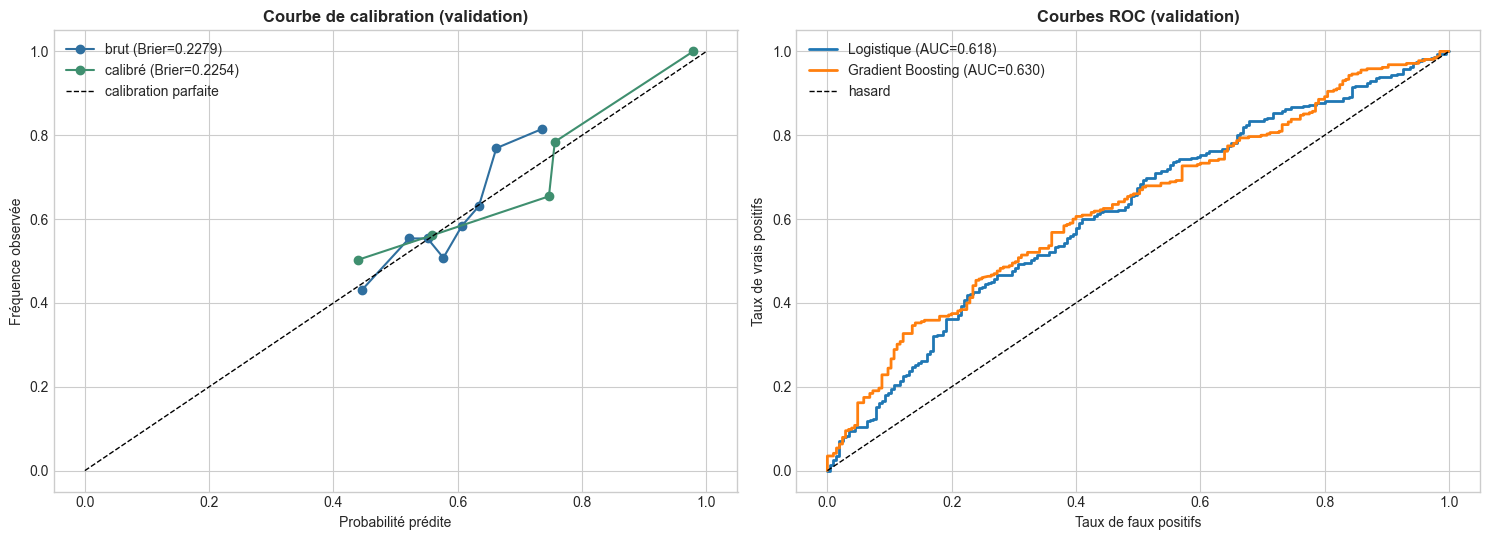

         n  p_predite  freq_observee  gap_moyen_pct
decile                                             
0       52     0.4314         0.3654        -0.9602
1       52     0.5122         0.6346         0.0885
2       52     0.5376         0.5577        -0.0293
3       52     0.5583         0.4808        -0.1035
4       52     0.5798         0.5192        -0.0287
5       52     0.6041         0.5962         0.0558
6       52     0.6266         0.6731         0.2975
7       52     0.6458         0.6346         0.1107
8       52     0.6753         0.7885         0.5955
9       52     0.7469         0.8077         0.9953

LECTURE : si le modèle est utile, gap_moyen_pct doit CROÎTRE avec le décile.
C'est le test le plus parlant : il montre que la probabilité prédite est reliée
à une grandeur économique (le rendement moyen), et pas seulement à un classement.



In [44]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

p_va = gb.predict_proba(va[FEATURES])[:, 1]

# Calibration d'un modèle DÉJÀ entraîné. L'API a changé entre les versions de
# scikit-learn : cv="prefit" avant la 1.6, FrozenEstimator depuis. On gère les deux.
def calibrer_modele_entraine(modele, X, y):
    try:
        from sklearn.frozen import FrozenEstimator          # scikit-learn >= 1.6
        return CalibratedClassifierCV(FrozenEstimator(modele), method="isotonic").fit(X, y)
    except ImportError:
        return CalibratedClassifierCV(modele, method="isotonic", cv="prefit").fit(X, y)

from sklearn.model_selection import train_test_split

# Découpage CHRONOLOGIQUE de la validation : shuffle=False impératif.
va_cal, va_ev = train_test_split(va, test_size=0.5, shuffle=False)
print(f"Calibration ajustée sur {len(va_cal)} lignes "
      f"({va_cal['Date'].min().date()} -> {va_cal['Date'].max().date()})")
print(f"Évaluée sur            {len(va_ev)} lignes "
      f"({va_ev['Date'].min().date()} -> {va_ev['Date'].max().date()})")

gb_cal = calibrer_modele_entraine(gb, va_cal[FEATURES], va_cal[CIBLE])

b_in_a  = brier_score_loss(va_cal[CIBLE], gb.predict_proba(va_cal[FEATURES])[:, 1])
b_in_p  = brier_score_loss(va_cal[CIBLE], gb_cal.predict_proba(va_cal[FEATURES])[:, 1])
b_out_a = brier_score_loss(va_ev[CIBLE],  gb.predict_proba(va_ev[FEATURES])[:, 1])
b_out_p = brier_score_loss(va_ev[CIBLE],  gb_cal.predict_proba(va_ev[FEATURES])[:, 1])

print(f"""
                        avant     après     gain
  DANS l'échantillon   {b_in_a:.4f}    {b_in_p:.4f}   {(b_in_a-b_in_p)/b_in_a*100:+5.1f} %
  HORS échantillon     {b_out_a:.4f}    {b_out_p:.4f}   {(b_out_a-b_out_p)/b_out_a*100:+5.1f} %  <-- À REPORTER

  Si le gain hors échantillon est nettement plus faible, la régression
  isotonique surajuste (elle peut créer autant de paliers que d'observations).
  Préférer alors method="sigmoid" (scaling de Platt), plus rigide mais plus
  stable sur petit échantillon.
""")

p_va = gb.predict_proba(va[FEATURES])[:, 1]
p_va_cal = gb_cal.predict_proba(va[FEATURES])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for etiquette, proba, couleur in [("brut", p_va, "#2f6f9f"), ("calibré", p_va_cal, "#3f8f6f")]:
    x_, y_ = calibration_curve(va[CIBLE], proba, n_bins=8, strategy="quantile")
    ax.plot(y_, x_, "o-", color=couleur, label=f"{etiquette} (Brier={brier_score_loss(va[CIBLE], proba):.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="calibration parfaite")
ax.set_xlabel("Probabilité prédite"); ax.set_ylabel("Fréquence observée")
ax.set_title("Courbe de calibration (validation)", fontweight="bold"); ax.legend()

ax = axes[1]
for nom, (m, feats) in [("Logistique", modeles["L-tout (les deux)"]),
                        ("Gradient Boosting", (gb, FEATURES))]:
    p = m.predict_proba(va[feats])[:, 1]
    fpr, tpr, _ = roc_curve(va[CIBLE], p)
    ax.plot(fpr, tpr, lw=2, label=f"{nom} (AUC={roc_auc_score(va[CIBLE], p):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="hasard")
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC (validation)", fontweight="bold"); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(DOCS, "06_fig_calibration_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

# Table de fiabilité par décile : la version chiffrée de la courbe
va_ = va.copy(); va_["p"] = p_va
va_["decile"] = pd.qcut(va_["p"], 10, labels=False, duplicates="drop")
fiab = va_.groupby("decile").agg(n=("p", "size"),
                                 p_predite=("p", "mean"),
                                 freq_observee=(CIBLE, "mean"),
                                 gap_moyen_pct=("gap", lambda s: s.mean() * 100)).round(4)
print(fiab.to_string())
print("""
LECTURE : si le modèle est utile, gap_moyen_pct doit CROÎTRE avec le décile.
C'est le test le plus parlant : il montre que la probabilité prédite est reliée
à une grandeur économique (le rendement moyen), et pas seulement à un classement.
""")

---
## §8 — Robustesse

Trois vérifications avant de toucher au bloc de test.

1. **Par ticker** — le modèle marche-t-il sur les 5 actions, ou tire-t-il tout son score de TSLA ?
2. **Par régime** — que devient la performance en marché baissier ?
3. **Leave-one-ticker-out** — le modèle généralise-t-il à une action **jamais vue** à l'entraînement ?
   C'est le test le plus exigeant, et le plus convaincant s'il passe.

In [45]:
# --- 8.1 performance par ticker ---
p_va_all = gb.predict_proba(va[FEATURES])[:, 1]
va_ = va.copy(); va_["p"] = p_va_all
lignes = []
for tk, g in va_.groupby("Ticker"):
    if g[CIBLE].nunique() < 2:
        continue
    lignes.append(dict(Ticker=tk, n=len(g),
                       AUC=round(roc_auc_score(g[CIBLE], g["p"]), 4),
                       MCC=round(matthews_corrcoef(g[CIBLE], (g["p"] >= 0.5).astype(int)), 4),
                       base=round(g[CIBLE].mean(), 3)))
print("8.1 — PERFORMANCE PAR TICKER (validation)")
print(pd.DataFrame(lignes).to_string(index=False))

# --- 8.2 leave-one-ticker-out ---
print("\n8.2 — LEAVE-ONE-TICKER-OUT (le modèle voit-il une action inconnue ?)")
lignes = []
for tk in sorted(d_wf["Ticker"].unique()):
    a = d_wf[(d_wf["Ticker"] != tk) & (d_wf["bloc"].isin(["train", "valid"]))]
    b = d_wf[(d_wf["Ticker"] == tk) & (d_wf["bloc"].isin(["train", "valid"]))]
    if len(a) < 300 or b[CIBLE].nunique() < 2:
        continue
    m = clone(pipeline_logit(1.0)).fit(a[FEATURES], a[CIBLE])
    auc = roc_auc_score(b[CIBLE], m.predict_proba(b[FEATURES])[:, 1])
    lignes.append(dict(Ticker_exclu=tk, n_test=len(b), AUC=round(auc, 4)))
lot = pd.DataFrame(lignes)
print(lot.to_string(index=False))
print(f"AUC moyenne hors échantillon transversal : {lot['AUC'].mean():.4f}")
print("""
Si ces AUC restent > 0.50, le signal n'est pas propre à une action :
il se transfère à un titre que le modèle n'a jamais vu. C'est l'argument
le plus fort contre l'accusation de surajustement.
""")

# --- 8.3 par régime ---
BORNES = [("Krach COVID", "2020-01-02", "2020-03-23"),
          ("Reprise / liquidité", "2020-03-24", "2020-12-31"),
          ("Euphorie retail", "2021-01-01", "2021-06-30"),
          ("Plateau / rotation", "2021-07-01", "2021-12-31"),
          ("Resserrement Fed", "2022-01-01", "2022-03-04")]

print("\n8.3 — PERFORMANCE PAR RÉGIME (walk-forward, modèle logistique)")
d_wf2 = d_wf.copy()
d_wf2["regime"] = "hors"
for nom, d0, d1 in BORNES:
    msk = (d_wf2["Date"] >= d0) & (d_wf2["Date"] <= d1)
    d_wf2.loc[msk, "regime"] = nom

pred = []
for j_tr, j_te in plis:
    a = d_wf2[d_wf2["Date"].isin(j_tr)]; b = d_wf2[d_wf2["Date"].isin(j_te)].copy()
    if len(a) < 200 or b[CIBLE].nunique() < 2:
        continue
    m = clone(pipeline_logit(1.0)).fit(a[FEATURES], a[CIBLE])
    b["p"] = m.predict_proba(b[FEATURES])[:, 1]
    pred.append(b)
if pred:
    P = pd.concat(pred)
    lignes = []
    for rg, g in P.groupby("regime"):
        if len(g) < 50 or g[CIBLE].nunique() < 2:
            continue
        lignes.append(dict(Regime=rg, n=len(g), AUC=round(roc_auc_score(g[CIBLE], g["p"]), 4)))
    print(pd.DataFrame(lignes).to_string(index=False))

8.1 — PERFORMANCE PAR TICKER (validation)
Ticker   n    AUC    MCC  base
  AAPL 104 0.6095 0.1910 0.577
  AMZN 104 0.6686 0.2344 0.606
  META 104 0.5831 0.0641 0.548
  NVDA 104 0.6296 0.0676 0.625
  TSLA 104 0.6580 0.2656 0.673

8.2 — LEAVE-ONE-TICKER-OUT (le modèle voit-il une action inconnue ?)
Ticker_exclu  n_test    AUC
        AAPL     481 0.6666
        AMZN     481 0.5989
        META     481 0.5988
        NVDA     481 0.5953
        TSLA     481 0.6516
AUC moyenne hors échantillon transversal : 0.6222

Si ces AUC restent > 0.50, le signal n'est pas propre à une action :
il se transfère à un titre que le modèle n'a jamais vu. C'est l'argument
le plus fort contre l'accusation de surajustement.


8.3 — PERFORMANCE PAR RÉGIME (walk-forward, modèle logistique)


             Regime   n    AUC
    Euphorie retail 620 0.5773
 Plateau / rotation 530 0.6180
Reprise / liquidité  50 0.5278


In [46]:
print("=" * 92)
print("8.4 — LE SIGNAL EST-IL SPÉCIFIQUE À L'ACTION, OU EST-CE LE MARCHÉ ?")
print("=" * 92)
print("""
  gap_excess = gap du titre − moyenne des gaps du jour sur les 5 titres.

  Si le sentiment ne prédisait que le marché (le Nasdaq ouvre en hausse, les
  cinq titres ouvrent en hausse), le signal disparaîtrait sur cette cible.
  S'il survit, il est SPÉCIFIQUE au titre — un résultat bien plus fort.
""")

lignes = []
for cible, libelle in [("y_gap", "gap brut"),
                       ("y_gap_excess", "gap en excès du marché")]:
    if cible not in df.columns:
        print(f"  [ABSENT] {cible} — vérifier le notebook 05 §5")
        continue
    d_ = df[df["bloc"].isin(["train", "purge_1", "valid"])].dropna(subset=[cible]).copy()
    s_ = []
    for j_tr, j_te in plis:
        a = d_[d_["Date"].isin(j_tr)]; b = d_[d_["Date"].isin(j_te)]
        if len(a) < 200 or b[cible].nunique() < 2:
            continue
        mm = clone(pipeline_logit(1.0)).fit(a[FEATURES], a[cible])
        s_.append(roc_auc_score(b[cible], mm.predict_proba(b[FEATURES])[:, 1]))
    lignes.append(dict(Cible=libelle, taux_base=round(d_[cible].mean(), 3),
                       AUC_wf=round(np.mean(s_), 4), std=round(np.std(s_), 4),
                       plis=len(s_)))

E = pd.DataFrame(lignes)
print(E.to_string(index=False))
E.to_csv(os.path.join(DOCS, "06_cible_gap_excess.csv"), index=False)

if len(E) == 2:
    perte = E["AUC_wf"].iloc[1] - E["AUC_wf"].iloc[0]
    print(f"""
  Perte en passant au gap en excès : {perte:+.4f}

  INTERPRÉTATION
    perte < 0,02      -> signal ENTIÈREMENT spécifique au titre. Excellent.
    0,02 <= perte < 0,05 -> majoritairement spécifique, composante de marché.
    perte >= 0,05     -> une part importante est un effet de marché commun.
""")


8.4 — LE SIGNAL EST-IL SPÉCIFIQUE À L'ACTION, OU EST-CE LE MARCHÉ ?

  gap_excess = gap du titre − moyenne des gaps du jour sur les 5 titres.

  Si le sentiment ne prédisait que le marché (le Nasdaq ouvre en hausse, les
  cinq titres ouvrent en hausse), le signal disparaîtrait sur cette cible.
  S'il survit, il est SPÉCIFIQUE au titre — un résultat bien plus fort.

                 Cible  taux_base  AUC_wf    std  plis
              gap brut      0.598  0.5951 0.0225     4
gap en excès du marché      0.472  0.5489 0.0218     4

  Perte en passant au gap en excès : -0.0462

  INTERPRÉTATION
    perte < 0,02      -> signal ENTIÈREMENT spécifique au titre. Excellent.
    0,02 <= perte < 0,05 -> majoritairement spécifique, composante de marché.
    perte >= 0,05     -> une part importante est un effet de marché commun.



---
## §9 — Évaluation finale sur le bloc de test

> ### ⚠️ À ne faire qu'une seule fois
>
> Le bloc de test (décembre 2021 → mars 2022) n'a jamais été utilisé jusqu'ici. Le chiffre obtenu ci-dessous
> est **le** chiffre du mémoire.
>
> Si le résultat déçoit, la tentation sera de revenir modifier le modèle puis de relancer cette cellule.
> **Ne le fais pas.** À partir du deuxième passage, le test devient une deuxième validation, et le chiffre
> annoncé n'a plus la signification qu'on lui prête. Un résultat modeste mais honnête est défendable ;
> un résultat optimisé sur le test ne l'est pas.
>
> Le modèle final est réentraîné sur **train + validation** réunis (plus de données = meilleure estimation),
> avec les hyperparamètres choisis **avant** d'ouvrir le test.

In [47]:
import datetime as _dt
_JOURNAL = os.path.join(DOCS, "JOURNAL_TEST.txt")
with open(_JOURNAL, "a", encoding="utf-8") as _f:
    _f.write(f"{_dt.datetime.now():%Y-%m-%d %H:%M:%S} | "
             f"spec={CFG.get('specification_retenue','?')} | "
             f"n_features={len(FEATURES)} | coupure={CFG.get('heure_coupure','?')}h\n")
print("Historique des exécutions du bloc de TEST :")
print(open(_JOURNAL, encoding="utf-8").read())
print("Chaque ligne consomme un 'regard' sur le test. Au-delà de deux, le\n"
      "chiffre annoncé n'a plus la valeur d'une évaluation en aveugle.\n")

trva = d[d["bloc"].isin(["train", "purge_1", "valid"])]

finaux = {
    "Logistique (tout)": (clone(pipeline_logit(1.0)), FEATURES),
    "Gradient Boosting": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                    ("clf", HistGradientBoostingClassifier(**prm_gb))]), FEATURES),
    "Sentiment seul":    (clone(pipeline_logit(1.0)), FEAT_SENT),
    "Contrôles seuls":   (clone(pipeline_logit(1.0)), FEAT_CTRL),
}

res_test, proba_test = [], {}
for nom, (proto, feats) in finaux.items():
    m = clone(proto).fit(trva[feats], trva[CIBLE])
    p = m.predict_proba(te[feats])[:, 1]
    proba_test[nom] = p
    res_test.append(evaluer(te[CIBLE], p, nom=nom))
res_test.append(evaluer(te[CIBLE], np.full(len(te), 0.99), nom="Référence : toujours hausse"))

final = afficher(res_test).sort_values("AUC", ascending=False)
print("=" * 100)
print(f"RÉSULTATS SUR LE TEST — {te['Date'].min().date()} à {te['Date'].max().date()} "
      f"({te['Date'].nunique()} jours, {len(te)} observations)")
print("=" * 100)
print(final[["modele", "n", "AUC", "MCC", "Brier", "Accuracy", "base_rate", "gain_vs_naif"]].to_string(index=False))
final.to_csv(os.path.join(DOCS, "06_RESULTATS_TEST.csv"), index=False)

# Intervalle de confiance sur l'AUC par bootstrap (le chiffre seul ne suffit pas)
meilleur_nom = final.iloc[0]["modele"]
if meilleur_nom in proba_test:
    p = proba_test[meilleur_nom]
    y = te[CIBLE].values

    # --- version par LIGNES (trop étroite, conservée pour comparaison) ---
    rng = np.random.default_rng(0); a_lig = []
    for _ in range(2000):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            a_lig.append(roc_auc_score(y[i], p[i]))
    lo1, hi1 = np.percentile(a_lig, [2.5, 97.5])

    # --- version par BLOCS DE JOURS (correcte) ---
    jours = np.sort(pd.unique(te["Date"]))
    # Les groupes sont repérés par POSITION et non par date. Une table indexée
    # par la date lève un KeyError : selon la version de pandas, unique() rend
    # des pd.Timestamp là où rng.choice restitue des np.datetime64, et les deux
    # ne se valent pas comme clés de dictionnaire.
    groupes = [np.where(te["Date"].values == d_)[0] for d_ in jours]
    rng = np.random.default_rng(0); a_blk = []
    for _ in range(2000):
        tir = rng.integers(0, len(groupes), len(groupes))
        idx = np.concatenate([groupes[k_] for k_ in tir])
        if len(np.unique(y[idx])) > 1:
            a_blk.append(roc_auc_score(y[idx], p[idx]))
    lo2, hi2 = np.percentile(a_blk, [2.5, 97.5])

    print(f"\n{meilleur_nom} — AUC test = {roc_auc_score(y, p):.4f}")
    print(f"  IC 95 % par LIGNES         : [{lo1:.4f} ; {hi1:.4f}]  largeur {hi1-lo1:.4f}")
    print(f"  IC 95 % par BLOCS DE JOURS : [{lo2:.4f} ; {hi2:.4f}]  largeur {hi2-lo2:.4f}"
          f"   <-- À REPORTER")
    print(f"""
  Le second est {(hi2-lo2)/max(hi1-lo1,1e-9):.1f} fois plus large. C'est la version correcte : les
  cinq titres d'un même jour réagissent au même choc de marché et ne
  constituent donc pas cinq observations indépendantes. Le nombre
  d'observations effectivement indépendantes est de l'ordre de {len(jours)}, non {len(y)}.
""")

# Sauvegarde des probabilités pour le backtest du notebook 08
sortie = te[["Date", "Ticker", "gap", "ret_oc", "ret_cc", CIBLE]].copy()
for nom, p in proba_test.items():
    sortie[f"p_{nom.split()[0].lower()}"] = p
sortie.to_csv(os.path.join(DATA, "PREDICTIONS_M1_TEST.csv"), index=False)
print(f"\nProbabilités sauvegardées -> PREDICTIONS_M1_TEST.csv ({len(sortie)} lignes)")

Historique des exécutions du bloc de TEST :
2026-09-10 02:34:59 | spec=A_stricte | n_features=18 | coupure=4.0h

Chaque ligne consomme un 'regard' sur le test. Au-delà de deux, le
chiffre annoncé n'a plus la valeur d'une évaluation en aveugle.

RÉSULTATS SUR LE TEST — 2021-12-06 à 2022-03-04 (62 jours, 310 observations)
                     modele   n    AUC    MCC  Brier  Accuracy  base_rate  gain_vs_naif
          Gradient Boosting 310 0.6757 0.2339 0.2375    0.5871     0.5097        0.0774
             Sentiment seul 310 0.6627 0.2245 0.2341    0.6032     0.5097        0.0935
          Logistique (tout) 310 0.6617 0.2164 0.2349    0.6000     0.5097        0.0903
            Contrôles seuls 310 0.5387 0.1152 0.2566    0.5355     0.5097        0.0258
Référence : toujours hausse 310 0.5000 0.0000 0.4806    0.5097     0.5097        0.0000

Gradient Boosting — AUC test = 0.6757
  IC 95 % par LIGNES         : [0.6126 ; 0.7332]  largeur 0.1207
  IC 95 % par BLOCS DE JOURS : [0.5977 ; 0.746

---
## §10 — Comment rédiger cette partie dans le mémoire

### La structure du paragraphe de résultats

1. **Rappeler la question** : peut-on prédire le signe du gap à partir du sentiment nocturne ?
2. **Donner le chiffre principal** avec son intervalle de confiance : « AUC = 0.5x [IC 95 % : ...] sur un
   test hors échantillon de N observations ».
3. **Comparer à la référence** : « contre 0.50 pour la référence naïve, et 0.5y pour un modèle utilisant
   uniquement les variables de marché ».
4. **Décomposer** : « l'apport net du sentiment est de +0.0z point d'AUC ».
5. **Montrer la stabilité** : « le signal est positif sur k plis sur 6 en validation glissante ».
6. **Poser les limites** : période courte, 5 actions technologiques, régime de marché atypique
   (COVID puis liquidité massive).

### Les erreurs à ne pas commettre

| Erreur | Pourquoi c'est un problème |
|--------|----------------------------|
| Annoncer l'accuracy sans la référence naïve | 56 % peut vouloir dire « aucune information » |
| Annoncer un seul chiffre sans intervalle | avec ~300 observations de test, l'IC sur l'AUC fait ±0.06 |
| Présenter un résultat de validation comme un résultat de test | ce n'est pas hors échantillon |
| Retoucher le modèle après avoir vu le test | le test perd toute valeur |
| Conclure « le modèle bat le marché » | l'AUC ne dit rien de la rentabilité — voir notebook 08 |

### Si le résultat est faible

C'est une issue **parfaitement acceptable**, et même attendue : la prédiction directionnelle sur données
journalières est difficile, et si elle était facile, elle aurait déjà été arbitrée.

Ce qui fait la valeur du mémoire n'est pas le niveau de l'AUC, c'est :

- l'**asymétrie démontrée** entre le gap (prévisible) et la séance (non prévisible) ;
- la **rigueur méthodologique** (anti-fuite, walk-forward, ablations, falsification) ;
- l'**honnêteté** de l'évaluation.

Un résultat négatif bien établi est un résultat. Un résultat positif mal contrôlé n'en est pas un.